# Stellar populations, IMFs, and custom compact objects
Microlensing depends on the compact-object mass spectrum through the Einstein radius, $\theta_E\propto\sqrt{M}$, and through the number of objects required to realize a fixed compact convergence. This tutorial compares built-in mass functions, constructs a scaled truncated Salpeter example, samples positions and velocities, accepts a direct catalog, implements a custom distribution, and shows illustrative map consequences. An initial mass function is only a convenient population model here. A scientific lens galaxy may require an evolved present-day mass function with remnants and binaries.

## Random seeds and reproducibility
An explicit `seed` reproduces the complete sampled compact-object realization, including masses, positions, and velocities. Reusing that field with the same source, trajectory, method, and stochastic-source seeds reproduces the light curve. Passing a `torch.Generator` instead gives the caller ownership of a stream that advances on every draw. If both `seed` and `generator` are omitted, the evolving global CPU PyTorch stream is used, so successive calls draw different fields. `torch.manual_seed(...)` can control that global stream, although explicit component seeds are clearer. For a compound simulation, use distinct recorded sub-seeds for the stellar field, intrinsic driver, and observation noise. Fixed seeds control stochastic inputs, but different devices, dtypes, or backends can still differ at floating-point roundoff.

In [1]:
from pathlib import Path
import math
import numpy as np
import torch
from matplotlib import pyplot as plt
import microcaustics as mc
import microcaustics.plotting as mcp
plt.rcParams.update(mcp.publication_style())
distances = mc.LensingDistances.from_redshifts(0.5, 1.5)
print(mcp.runtime_description())


Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0


## Built-in distributions and a scaled Salpeter example
`salpeter_mass_function` is a single truncated power law with $dN/dM\propto M^{-2.35}$. `kroupa_mass_function` is a continuous broken power law with low-mass breaks. Here we request a Salpeter slope, a mean mass of 0.3 solar masses, and a dynamic range of 100 rather than specifying the limits directly. Power laws are scale free, so we first calculate the mean for limits 1 and 100, then rescale both limits to obtain the requested mean exactly.

In [2]:
mass_ratio = 100.0
target_mean = 0.3
unit_salpeter = mc.salpeter_mass_function(1.0, mass_ratio)
salpeter_minimum = target_mean / unit_salpeter.mean_mass()
scaled_salpeter = mc.salpeter_mass_function(salpeter_minimum, mass_ratio * salpeter_minimum)
kroupa = mc.kroupa_mass_function(0.08, 10.0)
monodisperse = mc.PowerLawMassFunction(0.3, 0.3, 2.35)
mass_functions = {
    'Scaled Salpeter': scaled_salpeter,
    'Kroupa-like': kroupa,
    'Single mass': monodisperse,
}
for name, population in mass_functions.items():
    print(name, 'mean [Msun]=', f'{population.mean_mass():.4f}')
print('Scaled Salpeter bounds [Msun]=', scaled_salpeter.minimum_mass, scaled_salpeter.maximum_mass)

Scaled Salpeter mean [Msun]= 0.3000
Kroupa-like mean [Msun]= 0.4707
Single mass mean [Msun]= 0.3000
Scaled Salpeter bounds [Msun]= 0.09697081124093573 9.697081124093573


## Number-weighted masses and Einstein radii
The left panel is $dN/d\log_{10}M$, so it emphasizes how many lenses occur in each logarithmic interval rather than how much mass they contain. The right panel converts every sampled mass into its angular Einstein radius for the selected redshifts. Equal mean mass does not imply equal caustic structure. A broad distribution contains both numerous small lenses and rare large lenses.

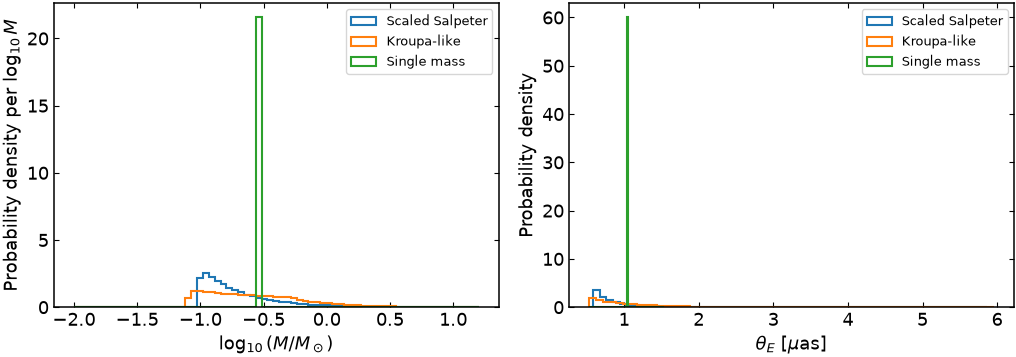

In [3]:
generator = torch.Generator().manual_seed(41)
samples = {name: population.sample(100_000, generator=generator, dtype=torch.float64) for name, population in mass_functions.items()}
figure, axes = plt.subplots(1, 2, figsize=(10.5, 3.9))
bins_mass = torch.linspace(-2.0, 1.2, 70).numpy()
for name, masses in samples.items():
    axes[0].hist(torch.log10(masses).numpy(), bins=bins_mass, histtype='step', density=True, linewidth=1.5, label=name)
    radii = distances.einstein_radius_uas(masses)
    axes[1].hist(radii.numpy(), bins=60, histtype='step', density=True, linewidth=1.5, label=name)
axes[0].set(xlabel=r'$\log_{10}(M/M_\odot)$', ylabel=r'Probability density per $\log_{10}M$')
axes[1].set(xlabel=r'$\theta_E$ [$\mu$as]', ylabel='Probability density')
for ax in axes:
    ax.legend(fontsize=9); ax.tick_params(direction='in', which='both', top=True, right=True)
figure.tight_layout()

## Realizing a finite stellar field
`PointMassField.sample_uniform` infers the expected object count from the requested region, the macro model's compact convergence, and the analytic mean mass. Here 25% of the convergence is smooth, so only $\kappa_*=\kappa(1-s)$ is assigned to point lenses. Positions are uniform in the exact rectangular field and velocities are independent Gaussian draws. Because masses are sampled, the realized $\kappa_*$ fluctuates around the target and is reported explicitly.

The stellar aperture is a physical modeling choice, not merely a memory setting. `rectangular_lens_region(..., light_loss=\epsilon)` maps the requested source rectangle through the macro eigenvalues and adds the stochastic point-mass margin $\theta_E(\langle M\rangle)\sqrt{\kappa_*\langle M^2\rangle/(\epsilon\langle M\rangle^2)}$. Thus `light_loss=0.01` controls the conventional finite-aperture estimate. It does **not** deliberately remove 1% of the final measured flux. Nevertheless, a hard rectangle can omit stars, rays, or caustics beyond its boundary.

The dynamic training examples therefore populate a complete circular stellar field whose diameter is 1.5 times the diagonal of that 1%-light-loss rectangle. This multiplicative safety scale is applied before drawing the stars, so it changes both the number of lenses and the work required. The tiled source scout then avoids tracing irrelevant cells while retaining the larger physical population. Increase the scale until the central source map and light curve converge. Decreasing it is unsafe merely because it is faster. Notebook 02 discusses how this physical aperture interacts with the numerical $N$, $k$, $r$, and $v$ controls.

Scaled Salpeter objects= 40 target kappa_*= 0.3375 realized kappa_*= 0.3793
Kroupa-like objects= 26 target kappa_*= 0.3375 realized kappa_*= 0.3709
Single mass objects= 40 target kappa_*= 0.3375 realized kappa_*= 0.3343


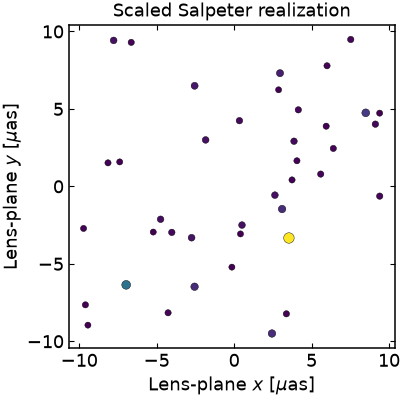

In [4]:
macro = mc.MacroLens(convergence=0.45, shear=0.35, shear_angle_deg=17.1887338539, smooth_matter_fraction=0.25)
lens_region = mc.PlaneRegion((20.0, 20.0))
fields = {}
for seed, (name, population) in enumerate(mass_functions.items(), start=101):
    field = mc.PointMassField.sample_uniform(
        lens_region, macro, distances, population, seed=seed,
        velocity_dispersion_uas_per_day=(2e-4, 1.5e-4),
    )
    fields[name] = field
    print(name, 'objects=', len(field), 'target kappa_*=', macro.compact_convergence,
          'realized kappa_*=', f'{mc.compact_convergence(field, lens_region):.4f}')
field = fields['Scaled Salpeter']
figure, ax = plt.subplots(figsize=(5.0, 4.2))
sizes = 12.0 + 45.0 * torch.sqrt(field.mass_solar / field.mass_solar.max())
ax.scatter(field.x_uas, field.y_uas, s=sizes, c=field.mass_solar, cmap='viridis', edgecolor='black', linewidth=0.3)
ax.set(xlabel=r'Lens-plane $x$ [$\mu$as]', ylabel=r'Lens-plane $y$ [$\mu$as]', title='Scaled Salpeter realization')
ax.set_aspect('equal'); ax.tick_params(direction='in', which='both', top=True, right=True)

## Direct catalogs and custom mass functions
Use `PointMassField` when masses or locations come from an external catalog, an N-body model, or a deliberately injected planet/black-hole population. Alternatively, any object with `sample(count, ...)` and `mean_mass()` methods satisfies the public mass-function protocol. This lognormal example is intentionally short. No package subclass is required.

In [5]:
catalog = mc.PointMassField(
    x_uas=[-2.0, 0.5, 1.7], y_uas=[0.2, -1.1, 1.4],
    mass_solar=[0.3, 1e-3, 30.0],
    velocity_x_uas_per_day=[0.0, 2e-4, -1e-4],
    velocity_y_uas_per_day=[1e-4, 0.0, 1e-4],
)
class LogNormalMassFunction:
    def __init__(self, median_mass, sigma_ln):
        self.median_mass = float(median_mass); self.sigma_ln = float(sigma_ln)
    def mean_mass(self):
        return self.median_mass * math.exp(0.5 * self.sigma_ln**2)
    def sample(self, count, *, generator=None, device='cpu', dtype=torch.float32):
        normal = torch.randn(int(count), generator=generator, device=device, dtype=dtype)
        return self.median_mass * torch.exp(self.sigma_ln * normal)
custom = LogNormalMassFunction(median_mass=0.2, sigma_ln=0.7)
custom_field = mc.PointMassField.sample_uniform(lens_region, macro, distances, custom, seed=300)
print('Direct catalog masses [Msun]:', catalog.mass_solar.tolist())
print('Custom lognormal analytic mean:', custom.mean_mass(), 'objects:', len(custom_field))

Direct catalog masses [Msun]: [0.30000001192092896, 0.0010000000474974513, 30.0]
Custom lognormal analytic mean: 0.25552426264097733 objects: 47


## Illustrative map consequences
These maps hold the macro model, physical field, compact-convergence target, source grid, and numerical IPM settings fixed while changing the population distribution. They use independent finite realizations, so individual differences are not an estimator of an IMF effect. Scientific population comparisons require many matched realizations and source convolutions. This gallery only shows that all population objects feed the same solver interface.

Independent static maps fused in batches of 3


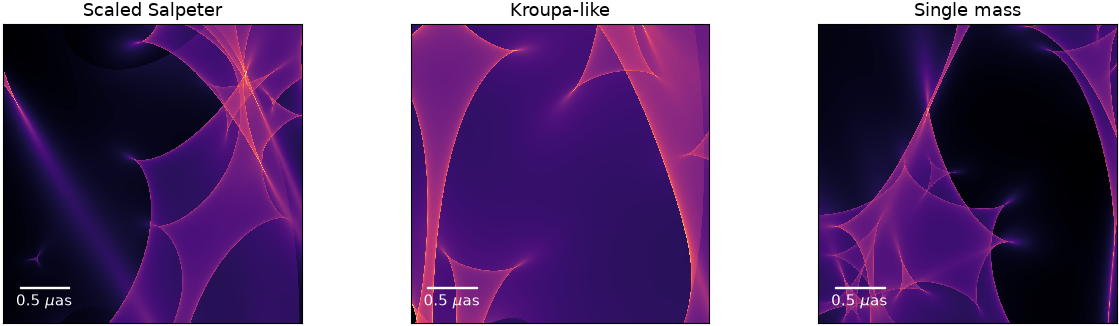

In [6]:
source_resolution = 1024 if torch.cuda.is_available() else 256
ray_count = 10_000_000 if torch.cuda.is_available() else 262_144
method = mc.production_ipm_config(
    scout_ratio=1,
    rays=ray_count,
    cell_chunk_size=524_288 if torch.cuda.is_available() else 65_536,
)
shared_runtime = mc.RuntimeConfig(
    device='cuda' if torch.cuda.is_available() else 'cpu',
    backend='triton' if torch.cuda.is_available() else 'auto',
)
systems = {
    name: mc.MicrolensingSystem(
        macro=macro,
        distances=distances,
        stars=population_field,
        lens_region=lens_region,
        runtime=shared_runtime,
    )
    for name, population_field in fields.items()
}
products = mc.batched_system_maps(
    tuple(systems.values()),
    map_width_uas=3.0,
    map_pixels=source_resolution,
    method=method,
    batch_size=len(systems),
)
maps = dict(zip(systems, products, strict=True))
print('Independent static maps fused in batches of', len(systems))
figure, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
for ax, (name, product) in zip(axes, maps.items(), strict=True):
    mcp.plot_magnification_map(
        product, ax=ax, colorbar=False, title=name,
        scale_bar_uas=0.5, show_axes=False,
    )
figure.tight_layout()
